In [ ]:
import matplotlib.pyplot as plt

from segmentation_project.data.loader import ImageLoader
from segmentation_project.ground_truth.overlay import Overlay
from segmentation_project.preprocessing.preprocessing import Grayscale
from segmentation_project.segmentation_models.sam_segmenter import SAMSegmenter

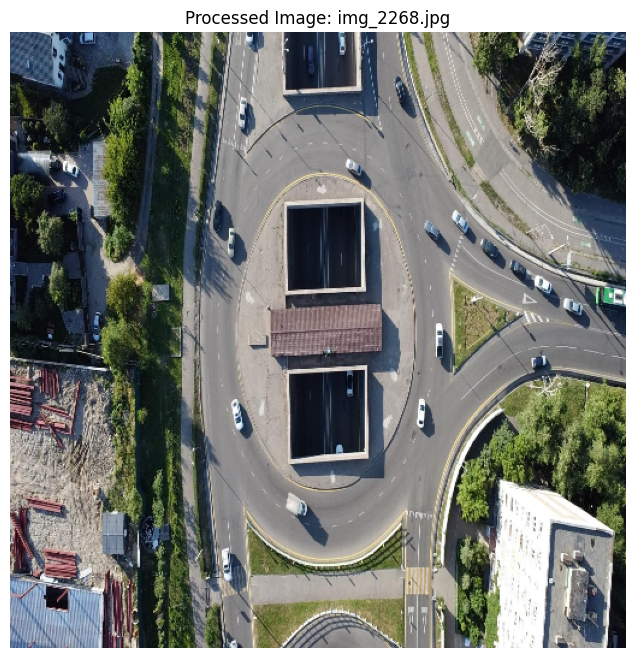

In [ ]:
# Initialize loader
loader = ImageLoader()

# List available images
image_paths = loader.list_images()

# Select image index
index = 0  # Change this index to select different images

# Load image
image = loader.load_image(image_paths[index])

# Preprocess image for SAM
processed_image = SAMSegmenter.preprocess_image(image)

# Display processed image

plt.figure(figsize=(12, 8))
plt.imshow(processed_image)
plt.title(f"Processed Image: " f"{image_paths[index].name}")
plt.axis("off")
plt.show()

In [ ]:
# Load SAM model
sam = SAMSegmenter.load_model()

# Generate SAM masks
masks = SAMSegmenter.generate_masks(
    sam=sam,
    image=processed_image,
)

print(f"{len(masks)} masks " f"generated by SAM.")

85 masks generated by SAM.


In [ ]:
# Filter very small masks
small_masks = SAMSegmenter.filter_small_masks(
    masks=masks,
    max_area=250,
)

print(f"{len(small_masks)} " f"small masks retained.")

26 small masks retained.


In [ ]:
# Create binary mask
binary_mask = SAMSegmenter.create_binary_mask(
    image_shape=processed_image.shape,
    masks=small_masks,
)

print("Binary mask created successfully.")

Binary mask created successfully.


In [ ]:
# Convert image to grayscale
grayscale_image = Grayscale.apply(processed_image)

# Create overlay
overlay_image = Overlay.apply(
    grayscale_image=grayscale_image,
    binary_mask=binary_mask,
)

print("Overlay created successfully.")

Overlay created successfully.


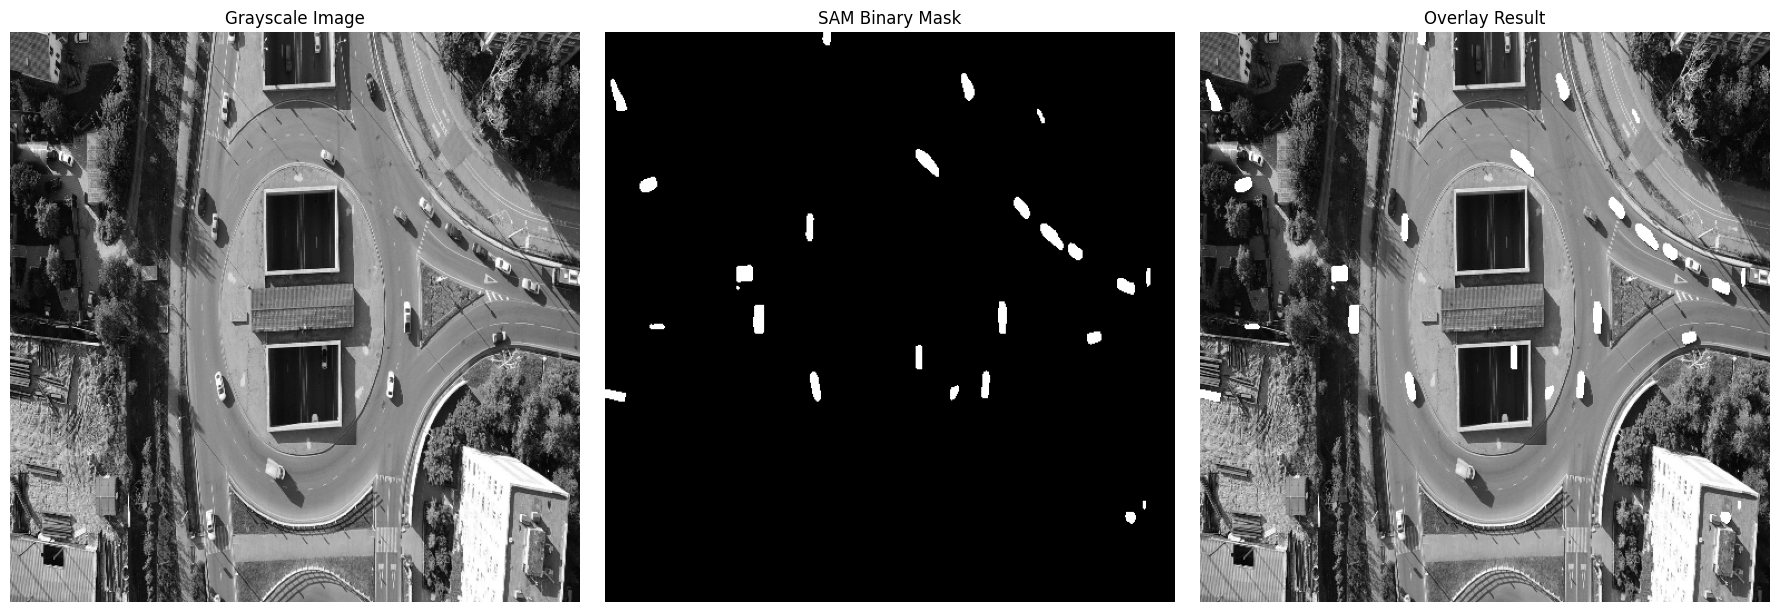

In [18]:
# Display results side-by-side

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
)


# Grayscale image
axes[0].imshow(
    grayscale_image,
    cmap="gray",
)

axes[0].set_title("Grayscale Image")

axes[0].axis("off")


# Binary mask
axes[1].imshow(
    binary_mask,
    cmap="gray",
)

axes[1].set_title("SAM Binary Mask")

axes[1].axis("off")


# Overlay image
axes[2].imshow(
    overlay_image,
    cmap="gray",
)

axes[2].set_title("Overlay Result")

axes[2].axis("off")

plt.tight_layout()
plt.show()